# SUPPORT VECTOR MACHINE

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

**Task 1: Exploratory Data Analysis (EDA)**

In [ ]:
df = pd.read_csv('Pharma_Industry.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [ ]:
df.shape

(500, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [ ]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [ ]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [ ]:
df.duplicated().sum()

np.int64(0)

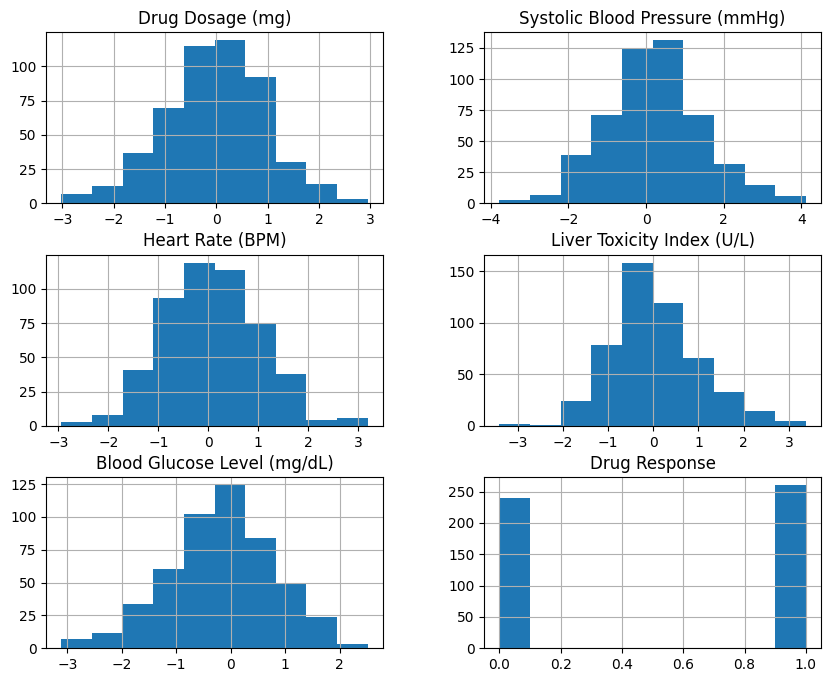

In [ ]:
# Histogram
df.hist(figsize=(10,8))
plt.show()


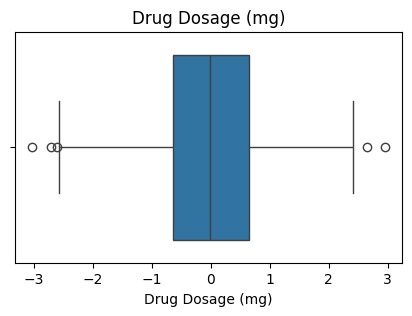

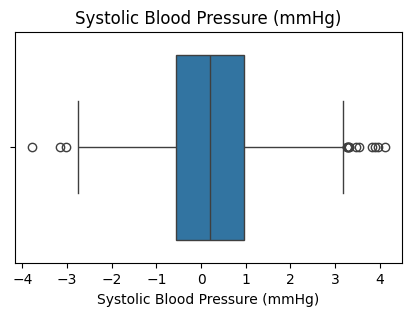

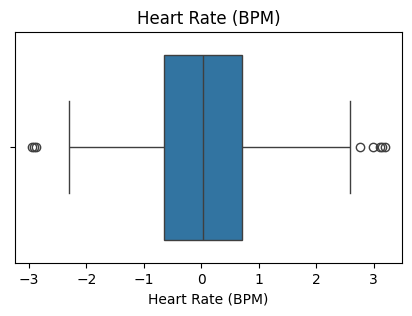

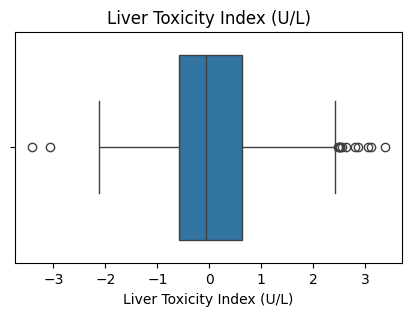

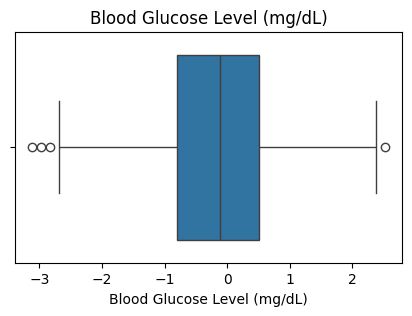

In [ ]:
# Box Plot
for col in df.columns[:-1]:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

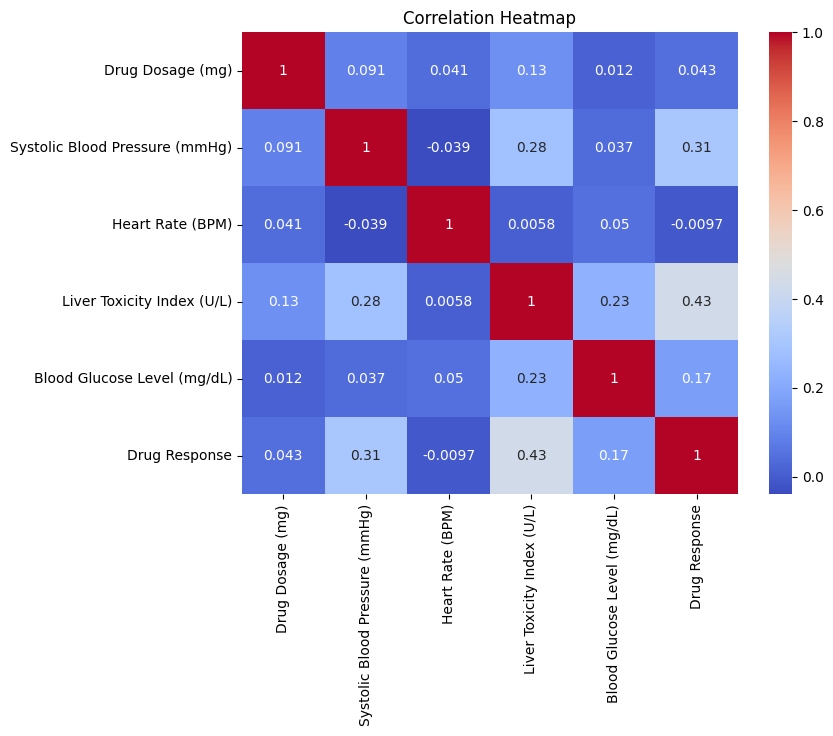

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Task 2: Data Preprocessing**

In [ ]:
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Task 3: Visualization**

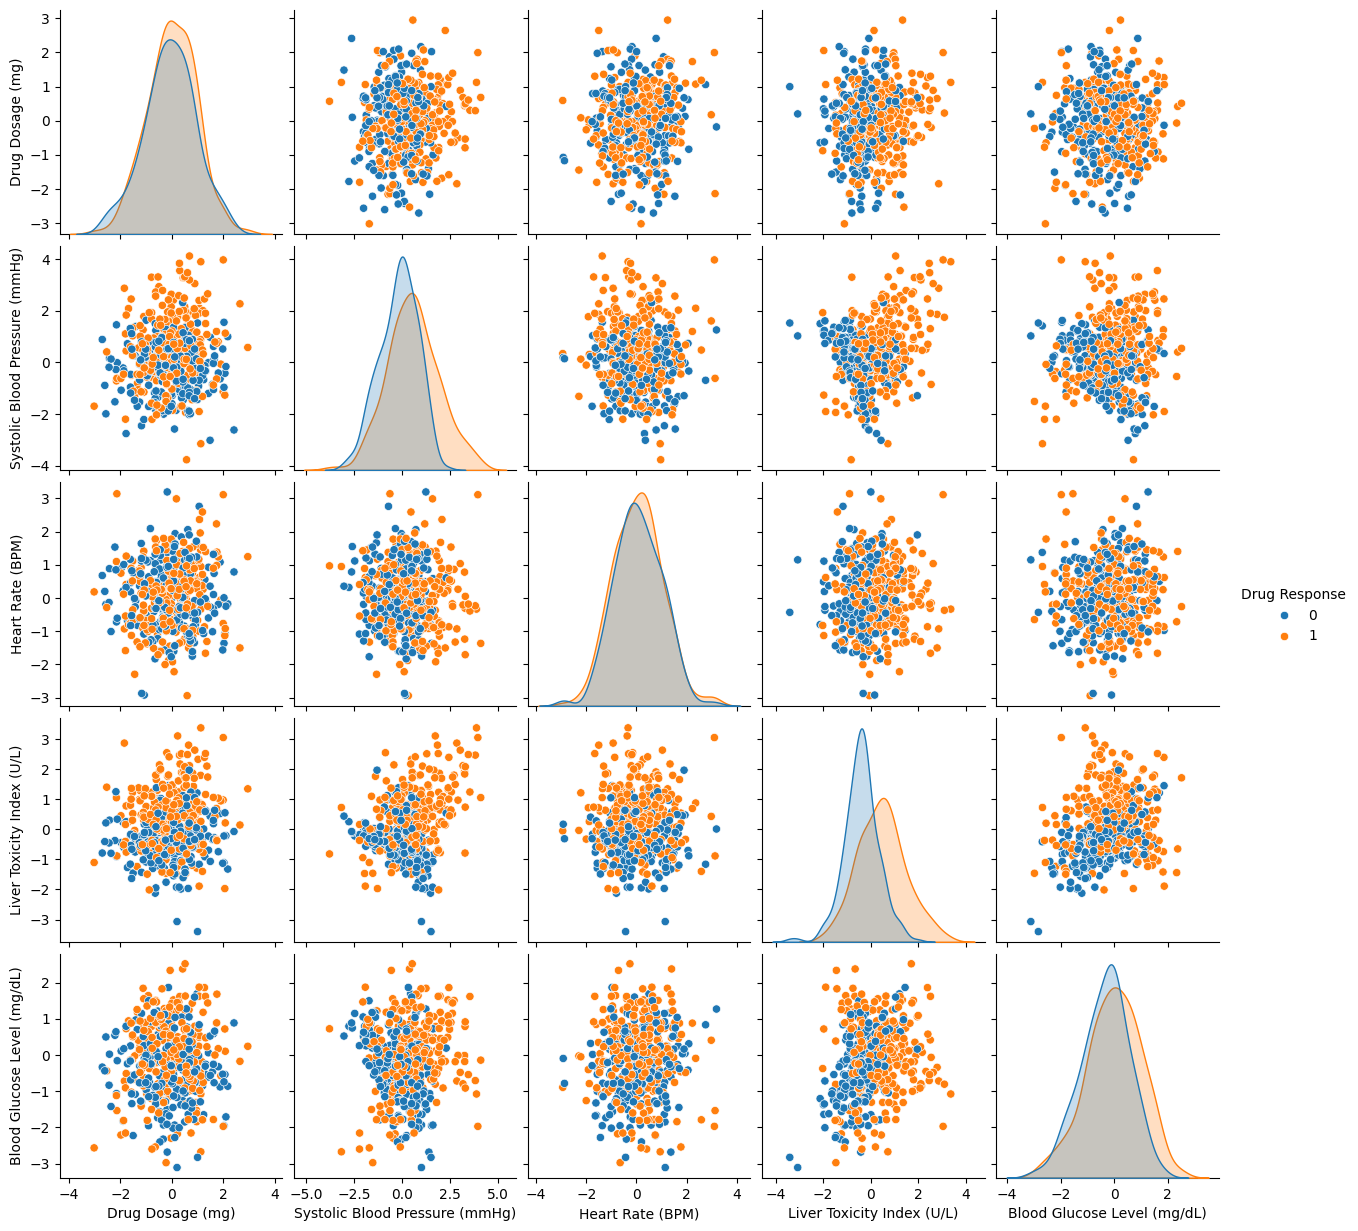

In [ ]:
sns.pairplot(df, hue='Drug Response')
plt.show()


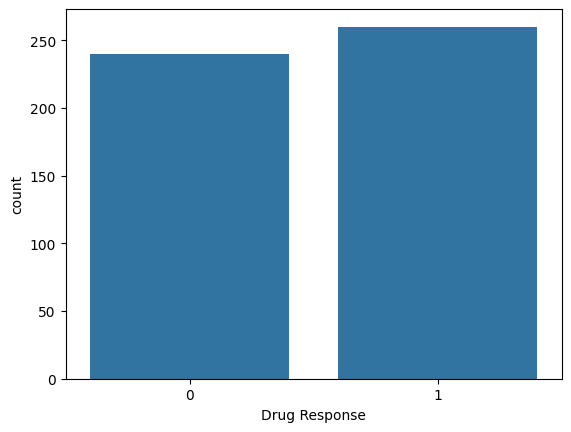

In [ ]:
sns.countplot(x='Drug Response', data=df)
plt.show()


**Task 4 & 6**: **SVM with Different Kernels**


In [ ]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
for kernel in kernels:

    svm = SVC(kernel=kernel)

    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)

    print(f"\nKernel: {kernel}")

    print("Accuracy:",
          accuracy_score(y_test, y_pred))

    print(classification_report(
        y_test,
        y_pred
    ))


Kernel: linear
Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100


Kernel: rbf
Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        44
           1       0.87      0.84      0.85        56

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100


Kernel: poly
Accuracy: 0.71
              precision    recall  f1-score   support

           0       0.62      0.91      0.73        44
           1       0.89      0.55      0.68        56

    accuracy                           0.71       100
   macro avg       0.75      0.73      0

## Final Model (RBF)

In [ ]:
svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)


#Task 5: Confusion Matrix

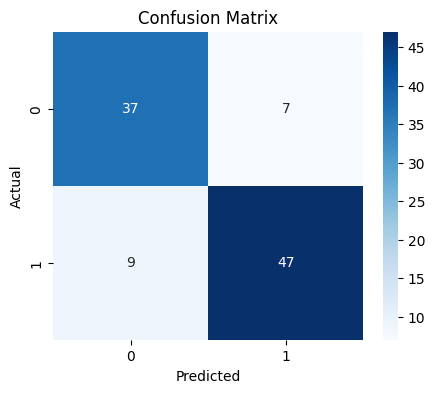

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Task 7: Comparison and Analysis**

| Kernel                      | Characteristics                                                          |
| --------------------------- | ------------------------------------------------------------------------ |
| Linear                      | Best for linearly separable data, faster training                        |
| Polynomial                  | Captures complex feature relationships                                   |
| RBF (Radial Basis Function) | Handles non-linear data effectively and usually provides higher accuracy |


***Analyze SVM Strengths and Weaknesses***

***Strengths of SVM***

*Effective for binary classification problems.

*Works well with high-dimensional data.

*Provides good accuracy and generalization.

*Can handle both linear and non-linear data using kernels.


***Weaknesses of SVM***

*Computationally expensive for large datasets.

*Sensitive to parameter selection (C and Gamma).

*Difficult to interpret compared to Decision Trees.

*Training time increases with dataset size.

**Practical Implications of SVM**

Support Vector Machine is widely used in real-world classification tasks such as:

Drug response prediction.

Disease diagnosis.

Medical image classification.

Cancer detection.

Spam email filtering.

Face recognition.

Personalized medicine.